# PD for Classification: Iris Example

This is demo of PD on both H2O and non-H2O models.

The Iris dataset, classification of iris plants into species.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from timeit import default_timer as timer

from sklearn import svm, datasets

from mli.explanation.pd import PD

### 1. Load the dataset

In [2]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

print(f"Class categories: {np.unique(y)}")

Class categories: [0 1 2]


### 2. Train and Test Split

In [3]:
# Reference: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

# Adding random noise
random_state = np.random.RandomState(0)
n_samples, n_features = X.shape
X_with_noise = np.c_[X, random_state.randn(n_samples, 5*n_features)]

X_train, X_test, y_train, y_test = train_test_split(X_with_noise, y, test_size=.2, random_state=0)

print(f"Number of features: {X_train.shape[1]}")
print(f"Number of rows(Train set): {len(X_train)}")
print(f"Number of rows(Test set): {len(X_test)}")

Number of features: 24
Number of rows(Train set): 120
Number of rows(Test set): 30


In [4]:
print(X_train[0])
print(y_train[0])

[ 6.4         3.1         5.5         1.8         1.69734648 -0.56660302
 -1.00326576  0.17462958  0.98232698  1.0374448   0.15919177 -0.98809669
 -0.50534072 -2.01828187 -0.91312154 -0.17845681  0.38900214 -0.33945432
 -0.05697905 -0.39618544  0.7510253  -0.89911294  0.83754791  1.96088081]
2


In [5]:
print(X_train.shape)
print(y_train.shape)

(120, 24)
(120,)


### 3. Basic Data Munging

In [6]:
import pandas as pd
feature_list_target = [f"f_{index}" for index in range(X_train.shape[1])] + ["target"]
print(feature_list_target)

# Persist the data to used for DAI
data_df_train = pd.DataFrame(data=np.c_[X_train, y_train],
                         columns=feature_list_target)
data_df_train['target'] = data_df_train['target'].astype('str')

# persist the frame
data_df_train.to_csv("iris_dataset.csv", index=False)

['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_22', 'f_23', 'target']


In [7]:
data_df_train.dtypes

f_0       float64
f_1       float64
f_2       float64
f_3       float64
f_4       float64
f_5       float64
f_6       float64
f_7       float64
f_8       float64
f_9       float64
f_10      float64
f_11      float64
f_12      float64
f_13      float64
f_14      float64
f_15      float64
f_16      float64
f_17      float64
f_18      float64
f_19      float64
f_20      float64
f_21      float64
f_22      float64
f_23      float64
target     object
dtype: object

In [8]:
data_df_train.head()

,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_15,f_16,f_17,f_18,f_19,f_20,f_21,f_22,f_23,target
0,6.4,3.1,5.5,1.8,1.697346,-0.566603,-1.003266,0.174630,0.982327,1.037445,...,-0.178457,0.389002,-0.339454,-0.056979,-0.396185,0.751025,-0.899113,0.837548,1.960881,2.0
1,5.4,3.0,4.5,1.5,0.100581,0.539161,0.086177,2.190898,0.983636,-0.085615,...,1.458715,2.153120,0.468305,0.112738,0.657268,-0.647054,0.171244,0.038909,0.626564,1.0
2,5.2,3.5,1.5,0.2,0.213480,-1.208574,-0.242020,1.518261,-0.384645,-0.443836,...,0.096321,0.942468,-0.267595,-0.678026,1.297846,-2.364174,0.020334,-1.347925,-0.761573,0.0
3,6.1,3.0,4.9,1.8,1.144554,-0.018767,1.283455,0.597946,2.188619,-0.219773,...,-1.548796,0.126569,0.793007,0.638024,0.340025,0.863017,-0.589698,-0.272533,0.737522,2.0
4,6.4,2.8,5.6,2.2,0.550789,0.595423,0.444853,-0.003763,-1.805936,-0.019323,...,0.372876,0.886293,-0.055259,-1.500328,-0.818504,0.818839,0.140496,0.649830,0.434789,2.0


### 4. Build a DAI model

In [9]:
# Built using 1.5rc19
# 1. Upload the data and build DAI model(adjusting the dial)
# 2. Download the scoring pipeline from DAI
# 3. Use the .whl and the requirements.txt to install the scoring pipeline

In [10]:
# If faced with a license error, generate a new one. 
import pandas as pd
import datatable as dt
import numpy as np
from numpy import nan
from scipy.special._ufuncs import expit
from scoring_h2oai_experiment_bavugake import Scorer


scorer = Scorer()

# Define a scoring function ...
def predict(X):
    # convert to datatable
    X = dt.Frame(X)
    return scorer.score_batch(X).iloc[:, 0]

('2019-01-03 14:59:35,177', 'License manager initialized')
('2019-01-03 14:59:35,179', '-----------------------------------------------------------------')
('2019-01-03 14:59:35,180', 'Checking whether we have a valid license...')
('2019-01-03 14:59:35,181', 'No Cloud provider found')
('2019-01-03 14:59:35,183', 'Read License from file as it was invalidated from environment')
('2019-01-03 14:59:35,184', 'License file exists (/home/ubuntu/.driverlessai/license.sig)')
('2019-01-03 14:59:35,191', '')
('2019-01-03 14:59:35,192', 'license_version:1')
('2019-01-03 14:59:35,193', 'serial_number:29')
('2019-01-03 14:59:35,194', 'licensee_organization:H2O.ai')
('2019-01-03 14:59:35,196', 'licensee_email:tomk@h2o.ai')
('2019-01-03 14:59:35,197', 'licensee_user_id:29')
('2019-01-03 14:59:35,198', 'is_h2o_internal_use:true')
('2019-01-03 14:59:35,199', 'created_by_email:tomk@h2o.ai')
('2019-01-03 14:59:35,200', 'creation_date:2018/11/26')
('2019-01-03 14:59:35,201', 'product:DriverlessAI')
('2019-

In [11]:
# Feature List
feature_list = feature_list_target[:-1]
print(feature_list)

# Select all column except the last 'target' column
x_train_df = data_df_train[feature_list]
print(x_train_df.head(2))

['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_22', 'f_23']
   f_0  f_1  f_2  f_3       f_4       f_5       f_6       f_7       f_8  \
0  6.4  3.1  5.5  1.8  1.697346 -0.566603 -1.003266  0.174630  0.982327   
1  5.4  3.0  4.5  1.5  0.100581  0.539161  0.086177  2.190898  0.983636   

        f_9    ...         f_14      f_15      f_16      f_17      f_18  \
0  1.037445    ...    -0.913122 -0.178457  0.389002 -0.339454 -0.056979   
1 -0.085615    ...    -1.604739  1.458715  2.153120  0.468305  0.112738   

       f_19      f_20      f_21      f_22      f_23  
0 -0.396185  0.751025 -0.899113  0.837548  1.960881  
1  0.657268 -0.647054  0.171244  0.038909  0.626564  

[2 rows x 24 columns]


In [ ]:
# Quick check

start = timer()
predicted_scores = predict(x_train_df)
end = timer()

#print(predicted_scores)
print(f"Run time in secs: {end - start}")

# observation
# Run time in secs: 105.06913930992596

In [18]:
predicted_scores.head()

0    0.006092
1    0.010378
2    0.985260
3    0.010933
4    0.005876
Name: target.0.0, dtype: float32

In [19]:
np.unique(x_train_df['f_0'])

array([4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5,
       5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8,
       6.9, 7. , 7.1, 7.2, 7.4, 7.6, 7.7, 7.9])

#### 4.1 Generate Explanation

In [ ]:
pdp = PD("Iris PD")
feature_names = ['f_0']
start = timer()
pdp.explain(features=feature_names, X=x_train_df, predict_method=predict)
end = timer()
print(end - start)

# Runtime: 1062.8840808970854 seconds

In [20]:
result1 = pdp.explanations()
result1

{'f_0':           4.30      4.66      5.02      5.38      5.74      6.10      6.46  \
 mean  0.325941  0.326722  0.326437  0.326267  0.325611  0.325553  0.324817   
 sd    0.454450  0.457368  0.458901  0.458908  0.459092  0.459060  0.455283   
 sem   0.041485  0.041752  0.041892  0.041892  0.041909  0.041906  0.041561   
 
           6.82      7.18      7.54  
 mean  0.327045  0.331847  0.336805  
 sd    0.452731  0.449283  0.445212  
 sem   0.041329  0.041014  0.040642  }

### 5. Build Non-DAI model (SK-learn)

In [21]:
from sklearn.multiclass import OneVsRestClassifier
clf = OneVsRestClassifier(svm.SVC(kernel='linear', probability=True,
                                 random_state=0))

In [22]:
x_train = data_df_train.iloc[:, :-1]
feature_list = list(x_train.columns[:-1])
print(x_train.shape)
print(x_train.head(1))
print(f"Feature List: {feature_list}")

# train a model
clf.fit(x_train, y_train)

(120, 24)
   f_0  f_1  f_2  f_3       f_4       f_5       f_6      f_7       f_8  \
0  6.4  3.1  5.5  1.8  1.697346 -0.566603 -1.003266  0.17463  0.982327   

        f_9    ...         f_14      f_15      f_16      f_17      f_18  \
0  1.037445    ...    -0.913122 -0.178457  0.389002 -0.339454 -0.056979   

       f_19      f_20      f_21      f_22      f_23  
0 -0.396185  0.751025 -0.899113  0.837548  1.960881  

[1 rows x 24 columns]
Feature List: ['f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11', 'f_12', 'f_13', 'f_14', 'f_15', 'f_16', 'f_17', 'f_18', 'f_19', 'f_20', 'f_21', 'f_22']


OneVsRestClassifier(estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=True, random_state=0, shrinking=True, tol=0.001,
  verbose=False),
          n_jobs=1)

#### 5.1 Quick Evaluation

In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

ytrain_predict = clf.predict(x_train)
ytest_predict = clf.predict(X_test)
target_names = list(np.unique(y_train).astype(str))

print("\n--------Train dataset classification report----------\n")
print(classification_report(y_train, ytrain_predict, target_names=target_names))

print("\n--------Test dataset classification report----------\n")
print(classification_report(y_test, ytest_predict, target_names=target_names))


--------Train dataset classification report----------

             precision    recall  f1-score   support

          0       1.00      1.00      1.00        39
          1       0.97      0.86      0.91        37
          2       0.90      0.98      0.93        44

avg / total       0.95      0.95      0.95       120


--------Test dataset classification report----------

             precision    recall  f1-score   support

          0       1.00      1.00      1.00        11
          1       0.85      0.85      0.85        13
          2       0.67      0.67      0.67         6

avg / total       0.87      0.87      0.87        30



In [24]:
x_train.iloc[0:1, :]

,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_14,f_15,f_16,f_17,f_18,f_19,f_20,f_21,f_22,f_23
0,6.4,3.1,5.5,1.8,1.697346,-0.566603,-1.003266,0.17463,0.982327,1.037445,...,-0.913122,-0.178457,0.389002,-0.339454,-0.056979,-0.396185,0.751025,-0.899113,0.837548,1.960881


In [25]:
# a quick check ...
clf.predict_proba(x_train.iloc[0:1, :])

array([[0.00399664, 0.26057073, 0.73543264]])

#### 5.2 Generate Explanation

In [26]:
from timeit import default_timer as timer

def predict_non_dai(X):
    return list(clf.predict_proba(X)[0])

In [27]:
from mli.explanation.pd import PD

pdp = PD("Iris Dataset")
feature_names = ['f_0']

In [28]:
start = timer()
pdp.explain(features=feature_names, X=x_train, predict_method=predict_non_dai)
end = timer()
print(end - start)

0.02716154302470386


In [29]:
result2 = pdp.explanations()
result2

{'f_0':           4.30      4.66      5.02      5.38      5.74      6.10      6.46  \
 mean  0.333333  0.333333  0.333333  0.333333  0.333333  0.333333  0.333333   
 sd    0.388900  0.386898  0.384503  0.381682  0.378405  0.374639  0.370356   
 sem   0.224531  0.223376  0.221993  0.220364  0.218472  0.216298  0.213825   
 
           6.82      7.18      7.54  
 mean  0.333333  0.333333  0.333333  
 sd    0.365534  0.360901  0.354508  
 sem   0.211041  0.208366  0.204675  }

### 6. Visualization

In [30]:
import matplotlib.pyplot as plt

def simple_plot(X, feature_name='f_0'):
    plt.subplot(1, 1, 1)
    plt.plot(X[feature_name].columns.values, X[feature_name].T['mean'].values, '.-')
    plt.xlabel(feature_name)
    plt.ylabel('P(class_0)')
    plt.title("one-way interaction - PDP")
    return plt

DAI Model ...


<module 'matplotlib.pyplot' from '/home/ubuntu/anaconda3/envs/mli_dev/lib/python3.6/site-packages/matplotlib/pyplot.py'>

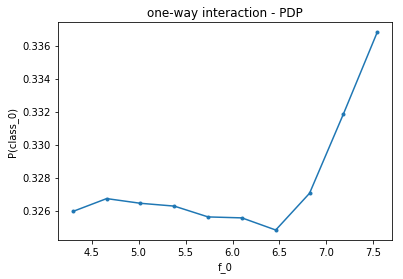

In [31]:
print("DAI Model ...")
simple_plot(result1)

Non DAI Model ...


<module 'matplotlib.pyplot' from '/home/ubuntu/anaconda3/envs/mli_dev/lib/python3.6/site-packages/matplotlib/pyplot.py'>

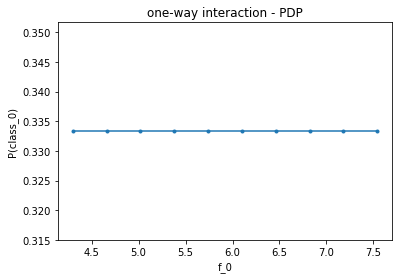

In [32]:
print("Non DAI Model ...")
simple_plot(result2)